In [1]:
import numpy as np
import pandas as pd

In [8]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

In [7]:
data = [['onion', 'beer', 'crisps', 'beef'],
        ['beer', 'tomato', 'crisps', 'eggs'],
        ['onion', 'crisps', 'eggs'],
        ['beer', 'eggs', 'beef'],
        ['onion', 'beer', 'carrot', 'crisps'],
        ['onion', 'eggs', 'beef'],
        ['onion', 'beer', 'carrot', 'crisps', 'eggs', 'beef'],
        ['onion', 'beer', 'crisps', 'eggs'],
        ['beer', 'tomato', 'carrot', 'eggs'],
        ['onion', 'crisps', 'eggs', 'beef'],
        ['beer', 'carrot', 'crisps', 'eggs']]

In [9]:
te = TransactionEncoder()

In [10]:
te.fit(data)

TransactionEncoder()

In [12]:
transcation = te.transform(data)

In [13]:
df = pd.DataFrame(transcation, columns=te.columns_)

In [14]:
df

,beef,beer,carrot,crisps,eggs,onion,tomato
0,True,True,False,True,False,True,False
1,False,True,False,True,True,False,True
2,False,False,False,True,True,True,False
3,True,True,False,False,True,False,False
4,False,True,True,True,False,True,False
5,True,False,False,False,True,True,False
6,True,True,True,True,True,True,False
7,False,True,False,True,True,True,False
8,False,True,True,False,True,False,True
9,True,False,False,True,True,True,False


In [15]:
freq_items = apriori(df, min_support=0.3, use_colnames=True)

In [16]:
freq_items

,support,itemsets
0,0.454545,(beef)
1,0.727273,(beer)
2,0.363636,(carrot)
3,0.727273,(crisps)
4,0.818182,(eggs)
5,0.636364,(onion)
6,0.363636,"(eggs, beef)"
7,0.363636,"(beef, onion)"
8,0.363636,"(carrot, beer)"
9,0.545455,"(crisps, beer)"


In [17]:
rules = association_rules(freq_items, metric="confidence", min_threshold=0.7)

In [18]:
rules

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(beef),(eggs),0.454545,0.818182,0.363636,0.800000,0.977778,1.0,-0.008264,0.909091,-0.040000,0.400000,-0.100000,0.622222
1,(beef),(onion),0.454545,0.636364,0.363636,0.800000,1.257143,1.0,0.074380,1.818182,0.375000,0.500000,0.450000,0.685714
2,(carrot),(beer),0.363636,0.727273,0.363636,1.000000,1.375000,1.0,0.099174,inf,0.428571,0.500000,1.000000,0.750000
3,(crisps),(beer),0.727273,0.727273,0.545455,0.750000,1.031250,1.0,0.016529,1.090909,0.111111,0.600000,0.083333,0.750000
4,(beer),(crisps),0.727273,0.727273,0.545455,0.750000,1.031250,1.0,0.016529,1.090909,0.111111,0.600000,0.083333,0.750000
5,(beer),(eggs),0.727273,0.818182,0.545455,0.750000,0.916667,1.0,-0.049587,0.727273,-0.250000,0.545455,-0.375000,0.708333
6,(crisps),(eggs),0.727273,0.818182,0.545455,0.750000,0.916667,1.0,-0.049587,0.727273,-0.250000,0.545455,-0.375000,0.708333
7,(crisps),(onion),0.727273,0.636364,0.545455,0.750000,1.178571,1.0,0.082645,1.454545,0.555556,0.666667,0.312500,0.803571
8,(onion),(crisps),0.636364,0.727273,0.545455,0.857143,1.178571,1.0,0.082645,1.909091,0.416667,0.666667,0.476190,0.803571
9,(onion),(eggs),0.636364,0.818182,0.454545,0.714286,0.873016,1.0,-0.066116,0.636364,-0.285714,0.454545,-0.571429,0.634921


# K-Means Algorithm

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [20]:
# Define the dataset
points = np.array([
    [2, 10],  # A
    [2, 5],   # B
    [8, 4],   # C
    [5, 8],   # D
    [7, 5]    # E
])

In [21]:
# Labels just for annotation
labels = ['A', 'B', 'C', 'D', 'E']

In [24]:
# Create KMeans model with 2 clusters
kmeans = KMeans(n_clusters=2, init='random', n_init=10, random_state=42)

In [25]:
kmeans.fit(points)

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(init='random', n_clusters=2, n_init=10, random_state=42)

In [26]:
# Get cluster assignments
clusters = kmeans.labels_

In [27]:
clusters

array([0, 0, 1, 0, 1], dtype=int32)

In [28]:
centroids = kmeans.cluster_centers_

In [29]:
centroids

array([[3.        , 7.66666667],
       [7.5       , 4.5       ]])

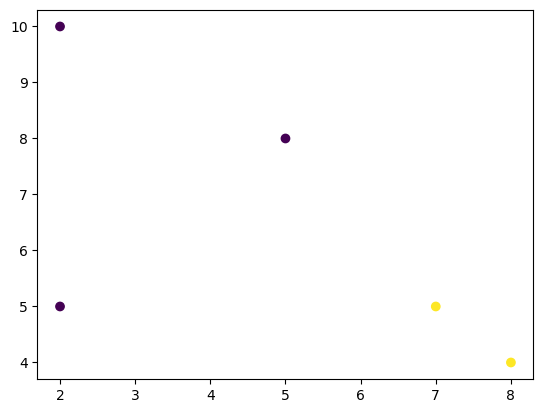

In [34]:
# Plot points colored by cluster
plt.scatter(points[:, 0], points[:, 1], c=clusters)